## **=> Kmeans**
---

##### **=> "customer Segmentation" based on their income and spending behavior**

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler

### **EDA**

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("shape: " ,df.shape, end="\n\n")
print("columns: " ,df.columns, end="\n\n")


shape:  (200, 5)

columns:  Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')



In [4]:
print("info: " ,df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
info:  None


In [5]:
print("Missing Values in Data:", df.isnull().sum().sum())
print("Duplicated Values in Data:", df.duplicated().sum().sum())

Missing Values in Data: 0
Duplicated Values in Data: 0


In [6]:
# Statistical Summary
print("Numerical Statistics:")
display(df.describe().T)

print("\nCategorical Statistics:")
display(df.describe(include='object').T)



Numerical Statistics:


,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0



Categorical Statistics:


,count,unique,top,freq
Genre,200,2,Female,112


In [7]:
df.drop(columns=['CustomerID'], inplace=True)

In [8]:
df.rename(columns={"Annual Income (k$)": "Annual_Income", "Genre" : "Gender", "Spending Score (1-100)" : "Spending_Score"}, inplace=True)

### **Feature Engineering**

In [9]:
bins_age = [18, 30, 50, 70]
labels_age = ['Young', 'Adult', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age, include_lowest=True)

bins_income = [0, 40, 85, 140]
labels_income = ['Low', 'Average', 'High']
df['Income_Level'] = pd.cut(df['Annual_Income'], bins=bins_income, labels=labels_income, include_lowest=True)

### **Visualization**

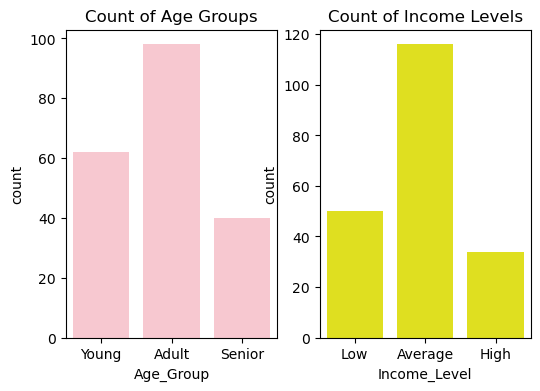

In [10]:
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='Age_Group', data=df, color="pink")
plt.title('Count of Age Groups')

plt.subplot(1, 2, 2)
sns.countplot(x='Income_Level', data=df, color="yellow")
plt.title('Count of Income Levels')

plt.show()

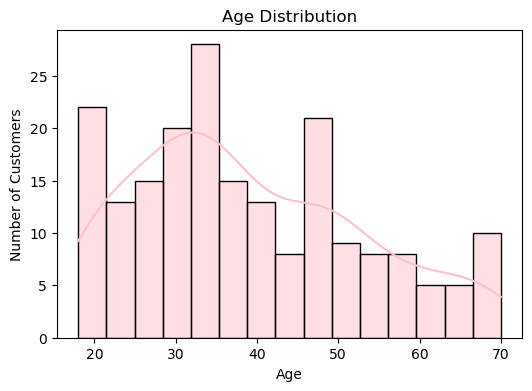

In [11]:
plt.figure(figsize=(6,4))

sns.histplot(df["Age"], bins= 15, kde=True, color="pink")

plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.title('Age Distribution')

plt.show()

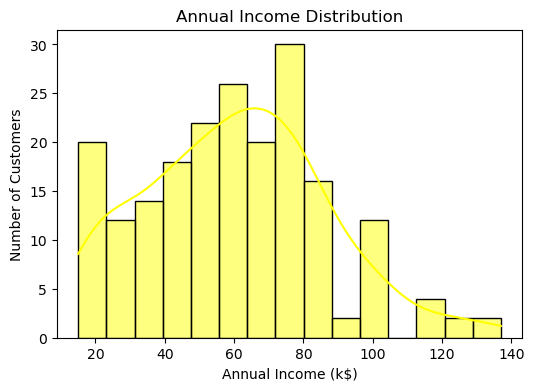

In [12]:
plt.figure(figsize=(6,4))

sns.histplot(df['Annual_Income'], bins=15, kde=True, color="yellow")

plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')
plt.title('Annual Income Distribution')

plt.show()

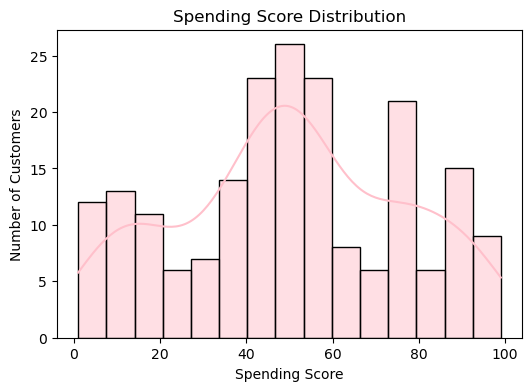

In [13]:
plt.figure(figsize=(6,4))

sns.histplot(df['Spending_Score'], bins=15, kde=True, color="pink")

plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')
plt.title('Spending Score Distribution')

plt.show()

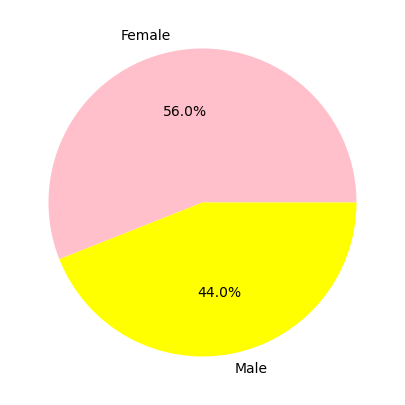

In [14]:
plt.figure(figsize=(6,5))

plt.pie(
    df["Gender"].value_counts(),
    labels=df["Gender"].value_counts().index,
    autopct="%1.1f%%",
    colors= ["pink", "yellow"]
)

plt.show()

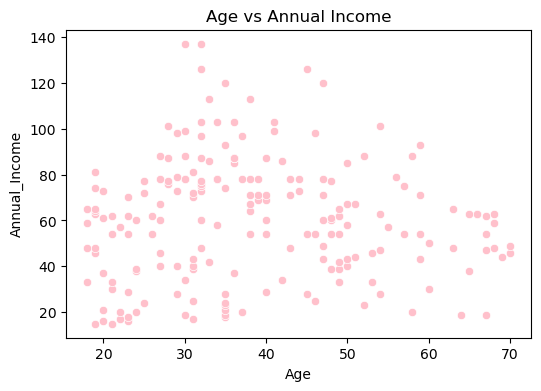

In [15]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data = df,
    color= "pink",
    x = "Age",
    y = "Annual_Income"
)
plt.title('Age vs Annual Income')
plt.show()

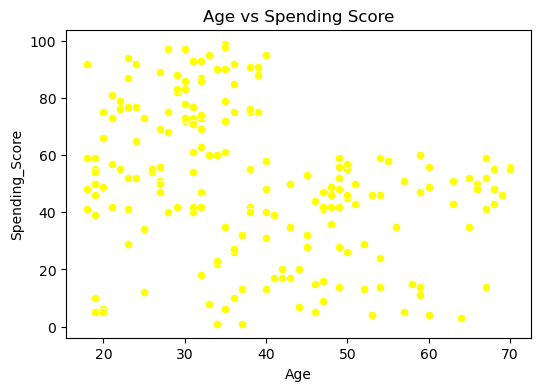

In [16]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending_Score',
    color= "yellow"
)

plt.title('Age vs Spending Score')
plt.show()

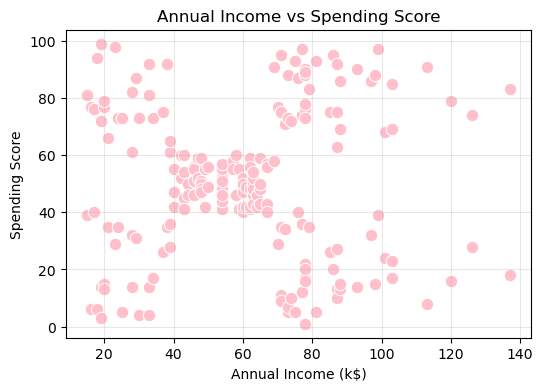

In [17]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    s=80,
    edgecolor='white',
    color= "pink"
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.grid(True, alpha=0.3)

plt.show()

### **Data Preprocessing**

In [18]:
X = df[['Annual_Income', 'Spending_Score']]

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Data: ")
display(X_scaled_df.head())

Scaled Data: 


,Annual_Income,Spending_Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


### **Determining Optimal Clusters (K)**

In [23]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.cluster import KMeans

In [31]:
# Elbow Method 1
inertia = []

for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

inertia



[269.691012192764,
 157.7040081503594,
 108.92131661364358,
 65.56840815571681,
 55.057348270386015,
 44.86475569922557]

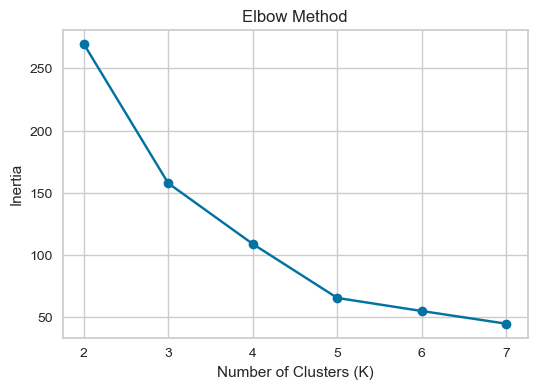

In [32]:
plt.figure(figsize=(6,4))

plt.plot(range(2,8), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

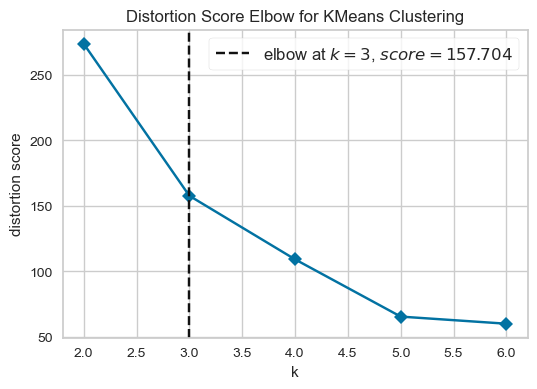

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [36]:
# Elbow Method 2
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,7), timings=False)

plt.figure(figsize=(6, 4))
visualizer.fit(X_scaled)
visualizer.show()

In [37]:
# Silhouette Analysis 1
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

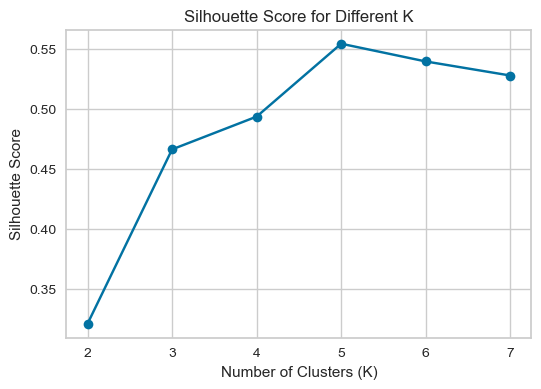

In [39]:
plt.figure(figsize=(6,4))

plt.plot(range(2,8), silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K')

plt.show()

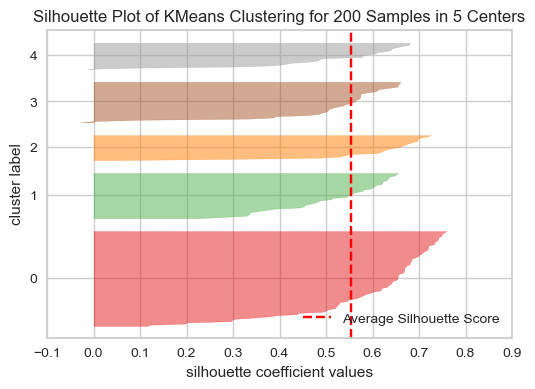

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 200 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [42]:
# Silhouette Analysis 2
model = KMeans(random_state=42, n_clusters=5)
visualizer2 = SilhouetteVisualizer(model)

plt.figure(figsize=(6, 4))
visualizer2.fit(X_scaled)
visualizer2.show()

### **kMeans Model**

In [43]:
kmean = KMeans(n_clusters=5, init='k-means++', random_state=42,)
df["cluster"] = kmean.fit_predict(X_scaled)

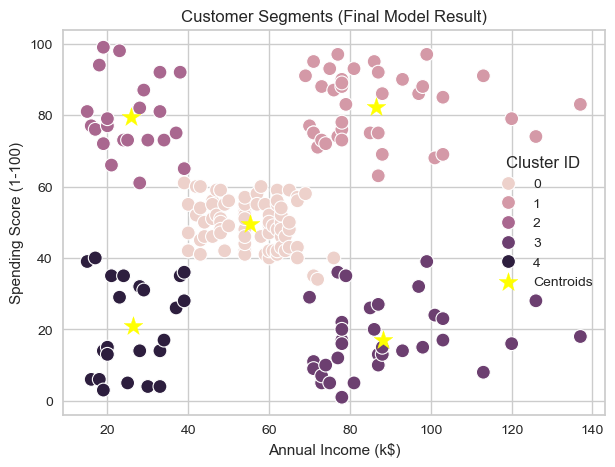

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Annual_Income", y="Spending_Score", 
                hue="cluster", s=100, legend='full', edgecolor='white')

# Convert the cluster centers back to their original scale after StandardScaler
centroids = scaler.inverse_transform(kmean.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, 
            c='yellow', marker='*', label='Centroids')

plt.title('Customer Segments (Final Model Result)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster ID')
plt.show()

In [52]:
prief = df.groupby('cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
prief['Count'] = df['cluster'].value_counts()
prief

,Age,Annual_Income,Spending_Score,Count
cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


In [ ]:
# Cluster 1 → (86.5, 82.1) → High / High
# Cluster 2 → (25.7, 79.4) → Low / High
# Cluster 3 → (88.2, 17.1) → High / Low
# Cluster 4 → (26.3, 20.9) → Low / Low
# Cluster 0 → (55.3, 49.5) → Middle / Middle

In [ ]:
# VIP: High Income & High Spend.
# Saver: High Income & Low Spend.
# Careless: Low Income & High Spend.
# Conservative: Low Income & Low Spend.
# Average: The middle ground.

In [54]:
centroids = scaler.inverse_transform(kmean.cluster_centers_)
centroid_df = pd.DataFrame(
    centroids,
    columns=['Income', 'Score']
)

centroid_df['Cluster_ID'] = range(5)

def get_cluster_name(row):
    income = row['Income']
    score = row['Score']
    
    if income > 70 and score > 60:
        return "VIP (High Income, High Spend)"
    elif income > 70 and score < 40:
        return "Saver (High Income, Low Spend)"
    elif income < 40 and score > 60:
        return "Careless (Low Income, High Spend)"
    elif income < 40 and score < 40:
        return "Conservative (Low Income, Low Spend)"
    else:
        return "Average (Middle Class)"

centroid_df['Cluster_Name'] = centroid_df.apply(
    get_cluster_name,
    axis=1
)

In [59]:
cluster_map = dict(
    zip(
        centroid_df['Cluster_ID'],
        centroid_df['Cluster_Name']
    )
)

df['Cluster_Name'] = df['cluster'].map(cluster_map)
df.head()

,Gender,Age,Annual_Income,Spending_Score,Age_Group,Income_Level,cluster,Cluster_Name
0,Male,19,15,39,Young,Low,4,"Conservative (Low Income, Low Spend)"
1,Male,21,15,81,Young,Low,2,"Careless (Low Income, High Spend)"
2,Female,20,16,6,Young,Low,4,"Conservative (Low Income, Low Spend)"
3,Female,23,16,77,Young,Low,2,"Careless (Low Income, High Spend)"
4,Female,31,17,40,Adult,Low,4,"Conservative (Low Income, Low Spend)"


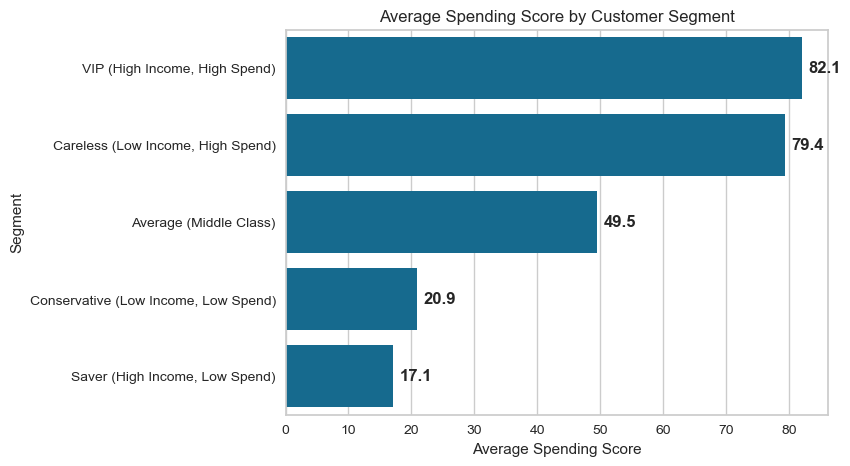

In [64]:
avg_spending = df.groupby('Cluster_Name')['Spending_Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=avg_spending.values, y=avg_spending.index)

plt.title('Average Spending Score by Customer Segment')
plt.xlabel('Average Spending Score')
plt.ylabel('Segment')

for index, value in enumerate(avg_spending.values):
    plt.text(value + 1, index, f'{value:.1f}', va='center', fontweight='bold')

plt.show()